In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('washington_ultimate.csv')

## Can I predict the price of a house?

The task is to predict the final sale price (lastSoldPrice) of residential properties in Washington State given features such as square footage, number of bedrooms/bathrooms, year built, property type, and ZIP code. The approach formulates this as a regression problem, using XGBoost as the primary model after establishing a Ridge Regression baseline. The target variable was log-transformed to handle price skewness before training. Our best model achieved an R² of 0.66 and a Mean Absolute Error of ~$105,000 on the held-out test set.

https://www.kaggle.com/datasets/kanchana1990/washington-real-estate-sold-properties-data-2026

In [3]:
print(df.tail())
print(df.describe())
print(df.info())
print(df.shape)
print(print(df.isnull().sum()))

           zip           type  year_built  listPrice  lastSoldPrice  \
12012  99218.0  single_family      1978.0   524957.0       504906.0   
12013  98251.0  single_family      1999.0   599927.0       589926.0   
12014  98251.0  single_family      2019.0   514909.0       512575.0   
12015  98258.0  single_family      1993.0   599874.0       624935.0   
12016  98310.0  single_family      1955.0   439912.0       433077.0   

       list_to_sold_ratio    sqft  price_per_sqft  stories  beds  baths  \
12012              0.9618  3270.0          154.41      NaN   4.0    3.0   
12013              0.9833  1710.0          344.99      2.0   3.0    3.0   
12014              0.9955  1810.0          283.19      2.0   3.0    2.0   
12015              1.0418  1090.0          573.33      1.0   3.0    2.0   
12016              0.9845  1300.0          333.14      1.0   3.0    2.0   

       baths_full  baths_full_calc  garage  \
12012         3.0              3.0     2.0   
12013         2.0             

## Phase 1: Data Loading and Initial Look

* **Total Rows:** 12,017
* **Total Features:** 15

| Feature | Data Type | Range / Values | Missing Values | Outliers Found |
| :--- | :--- | :--- | :--- | :--- |
| **zip** | Categorical | 98001 to 99403 | 3 | None (Location) |
| **type** | Categorical | Single Family, Multi-Family, etc. | 0 | None |
| **year_built** | Numerical | 1875 to 2026 | 860 | None |
| **listPrice** | Numerical | \$1k to \$10.9M | 1,692 | Yes (\$10M+) |
| **lastSoldPrice** | **Target (Num)** | \$1k to \$15.7M | 15 | Yes (\$15M+) |
| **sqft** | Numerical | 120 to 29,680 | 872 | Yes (29k sqft) |
| **stories** | Numerical | 0 to 31 | 1,511 | Yes (31 stories) |
| **beds** | Numerical | 0 to 18 | 932 | Yes (18 beds) |
| **baths** | Numerical | 0 to 20 | 484 | Yes (20 baths) |
| **garage** | Numerical | 1 to 10 | 9,654 | None |

---

### Key Observations & Definitions

* **Target Assessment:** The target variable is `lastSoldPrice`. The extreme range (\$1k - \$15.7M) suggests significant variance in the market.
* **Missing Data Strategy:** The `garage` feature is missing over 80% of its data (9,654 nulls). These will be filled with `0` assuming no garage is present.
* **Outlier Definition:** Outliers are defined as data points that deviate significantly from the norm, such as houses with 31 stories, 18 bedrooms, or sales prices under \$5,000, which may represent non-market transactions.
* **Data Preparation Needs:** Categorical features like `zip` and `type` must be converted to strings and one-hot encoded for the model to process them.

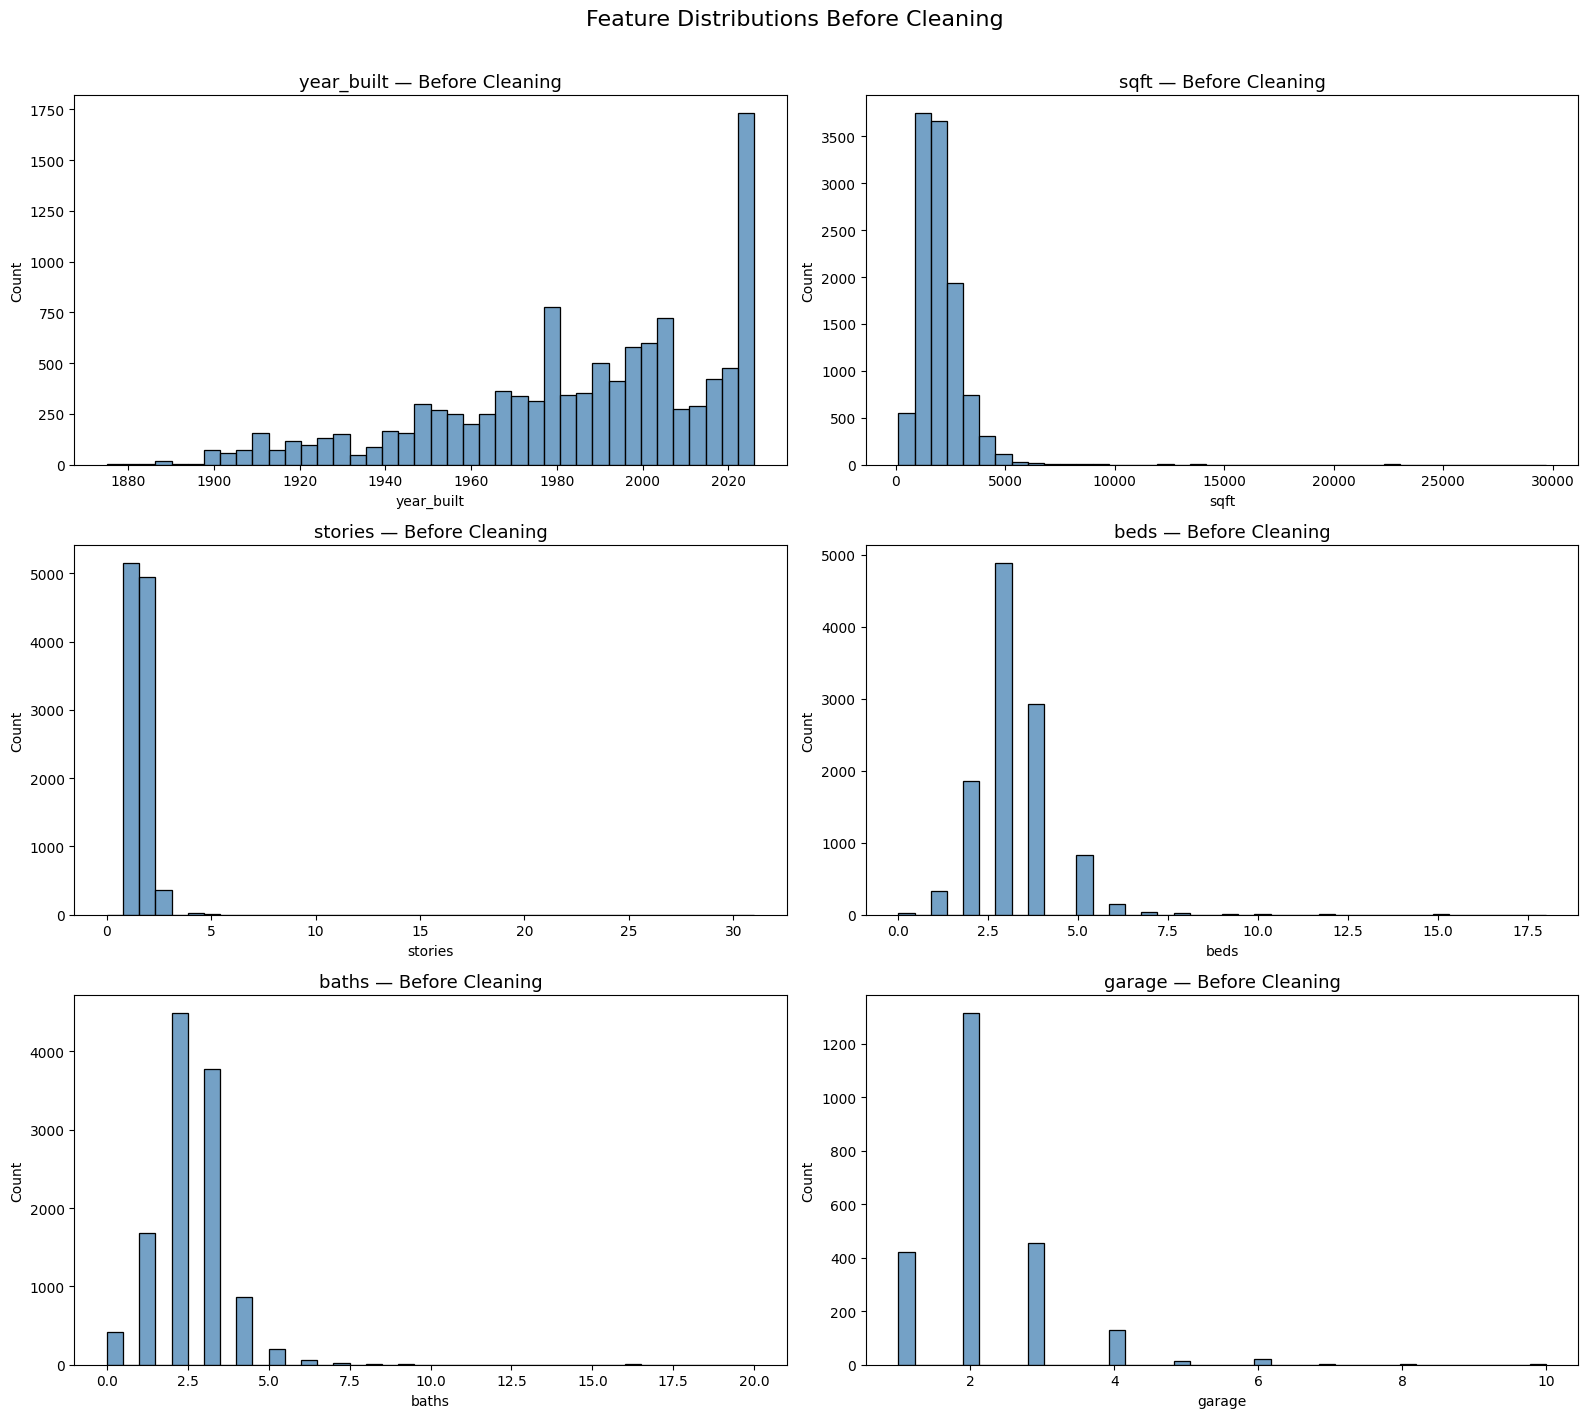

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
#BEFORE CLEANING 
numerical_features = ['year_built', 'sqft', 'stories', 'beds', 'baths', 'garage']

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.histplot(
        data=df,
        x=feature,
        ax=axes[i],
        bins=40,
        color='steelblue'
    )
    axes[i].set_title(f'{feature} — Before Cleaning', fontsize=13)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')

plt.suptitle('Feature Distributions Before Cleaning', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

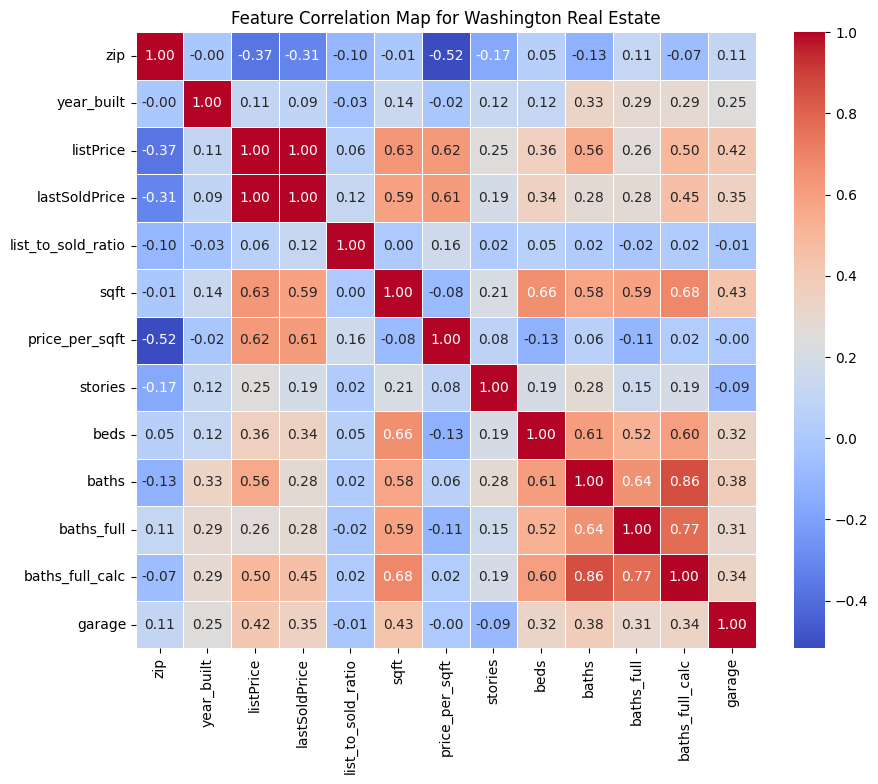

In [5]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Feature Correlation Map for Washington Real Estate')
plt.show()

In [6]:
#Some notes i got. listPrice can be a leak for my data since its highly correlated to the soldPrice. TAKE IT OUT
#list_to_sold_ratio is another leak since it calculates the ratio using the soldPrice. DROP IT
#price_per_sqrt is another leak. DROP IT
#baths full has the same correlation to price so I can drop it.

In [7]:
cols_to_keep = [
    'zip', 'year_built', 'sqft', 'stories', 
    'beds', 'baths', 'garage', 'lastSoldPrice','type'
]
df_clone = df[cols_to_keep].copy()
df_clone = df_clone.dropna(subset=['lastSoldPrice'])  #I dropped the NA values of lastSoldPrice because it was only 15 rows which is not a lot compared to 12k rows
print(f"Original shape: {df.shape}")
print(f"Clone shape: {df_clone.shape}")
print(df_clone.head())

#Specifically fill 'garage' with 0
df_clone['garage'] = df_clone['garage'].fillna(0)

#Fill any remaining NaNs with the Median
#This ensures columns like beds/baths/sqft get typical values, not 0s.
df_clone = df_clone.fillna(df_clone.median(numeric_only=True))

#ONE-HOT ENCODE the 'type' column
#This turns 'type' into columns like 'type_condo', 'type_house', etc.
df_clone = pd.get_dummies(df_clone, columns=['type'], prefix='type')

#Verify there are no more missing values
print(df_clone.isnull().sum())
print(df_clone.head())
print(df_clone.shape)
print(df.shape)

#Create the region
df_clone['region'] = df_clone['zip'].astype(str).str[:3]

#Convert ZIP to a string so the model treats it as a category, not a number (Step 2)
df_clone['zip_cat'] = df_clone['zip'].astype(str)

#One-Hot Encode BOTH
# This captures the broad region AND the specific neighborhood
df_clone = pd.get_dummies(df_clone, columns=['region', 'zip_cat'], prefix=['reg', 'zip'])

#drop the original numerical zip
df_clone = df_clone.drop(columns=['zip'])

print(f"New Shape: {df_clone.shape}") 

Original shape: (12017, 15)
Clone shape: (12002, 9)
       zip  year_built    sqft  stories  beds  baths  garage  lastSoldPrice  \
0  99156.0      1997.0  2710.0      1.0   3.0    3.0     3.0       875085.0   
1  99006.0      1900.0  1460.0      2.0   3.0    2.0     NaN       347902.0   
2  98843.0      2017.0  3770.0      2.0   4.0    4.0     NaN      2539927.0   
3  98311.0      1990.0  4250.0      2.0   3.0    4.0     NaN       744599.0   
4  98102.0      1926.0  3500.0      2.0   3.0    3.0     NaN      1790076.0   

            type  
0  single_family  
1  single_family  
2  single_family  
3  single_family  
4  single_family  
zip                   0
year_built            0
sqft                  0
stories               0
beds                  0
baths                 0
garage                0
lastSoldPrice         0
type_condo            0
type_coop             0
type_farm             0
type_land             0
type_mobile           0
type_multi_family     0
type_other            0

In [8]:
# Calculate the 'middle' range
Q1 = df_clone['lastSoldPrice'].quantile(0.25)
Q3 = df_clone['lastSoldPrice'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds (1.5 is the standard multiplier)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the data
df_final = df_clone[(df_clone['lastSoldPrice'] >= lower_bound) & (df_clone['lastSoldPrice'] <= upper_bound)]

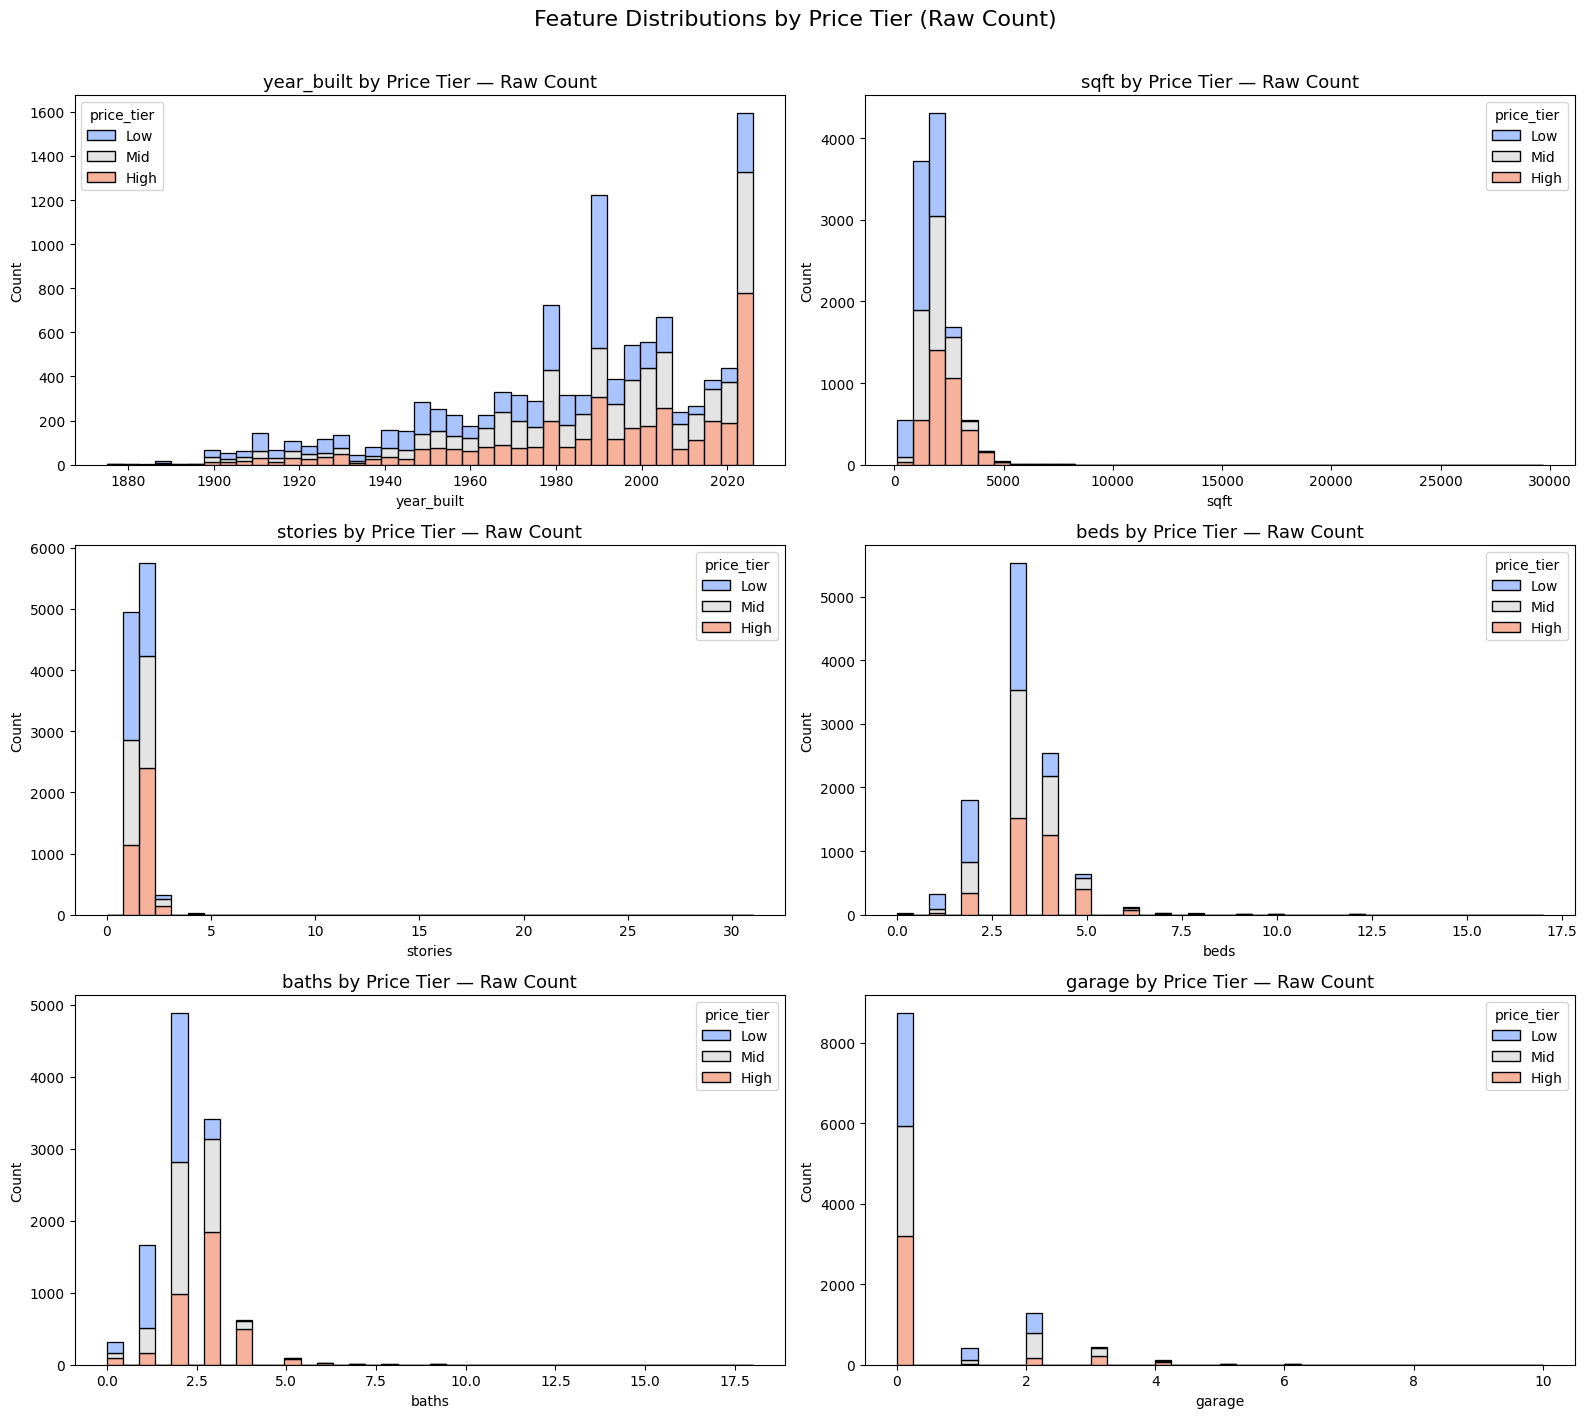

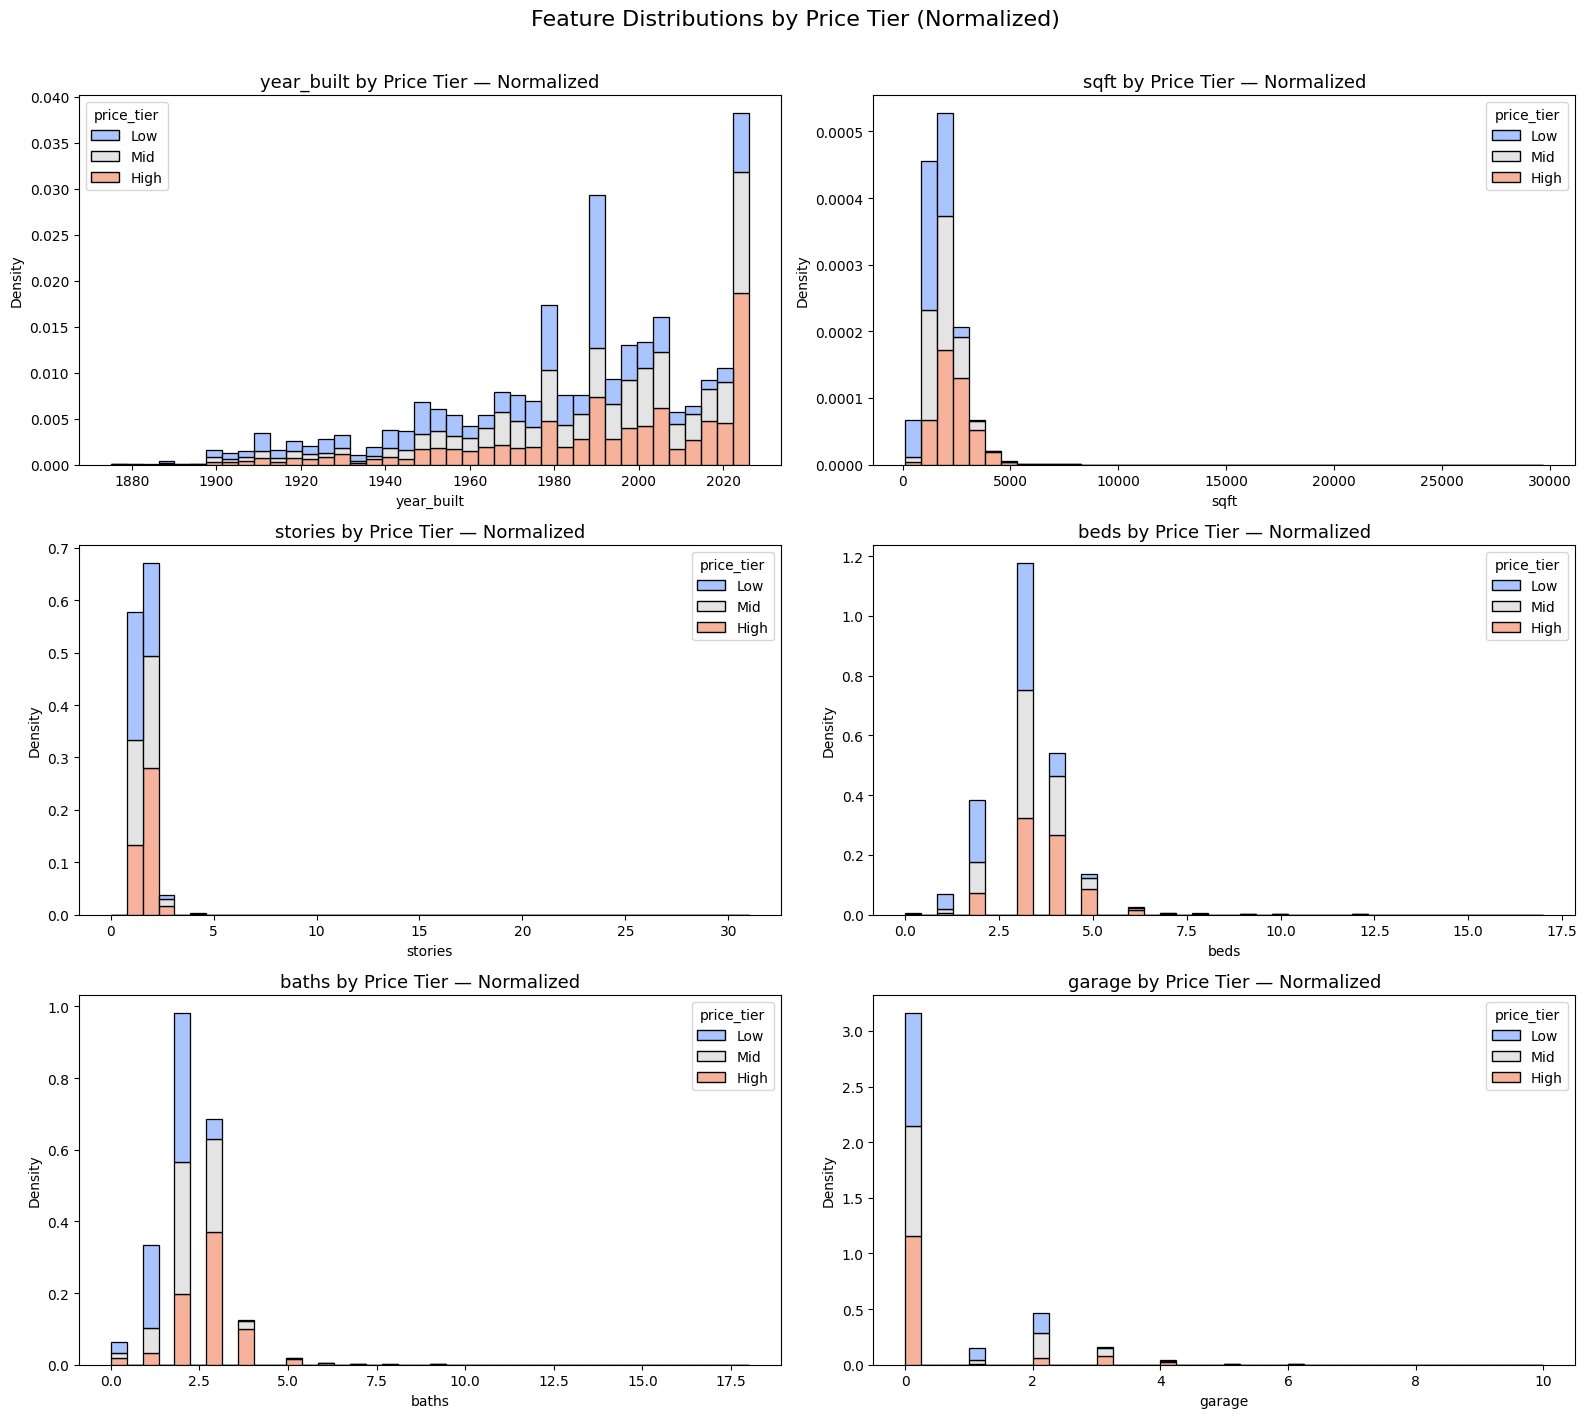

Property Type Distribution by Price Tier:
                Low   Mid  High
condo           535   255   204
coop              5     0     0
farm              1     3     3
land            474    28    33
mobile          482   118    22
multi_family     32    71    68
other            49    18    19
single_family  2008  3022  3052
townhomes        99   170   284


C:\Users\emanu\AppData\Local\Temp\ipykernel_5276\777608808.py:60: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  type_summary = df_viz.groupby('price_tier')[type_cols].sum().T


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_viz = df_final.copy()
df_viz['price_tier'] = pd.qcut(df_viz['lastSoldPrice'], 3, labels=['Low', 'Mid', 'High'])

numerical_features = ['year_built', 'sqft', 'stories', 'beds', 'baths', 'garage']

# ── RAW COUNT ──────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.histplot(
        data=df_viz,
        x=feature,
        hue='price_tier',
        multiple='stack',
        stat='count',
        ax=axes[i],
        bins=40,
        palette='coolwarm'
    )
    axes[i].set_title(f'{feature} by Price Tier — Raw Count', fontsize=13)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')

plt.suptitle('Feature Distributions by Price Tier (Raw Count)', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig('price_tiers_count.png', bbox_inches='tight')
plt.show()

# ── NORMALIZED DENSITY ──────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.histplot(
        data=df_viz,
        x=feature,
        hue='price_tier',
        multiple='stack',
        stat='density',
        ax=axes[i],
        bins=40,
        palette='coolwarm'
    )
    axes[i].set_title(f'{feature} by Price Tier — Normalized', fontsize=13)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Density')

plt.suptitle('Feature Distributions by Price Tier (Normalized)', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig('price_tiers_density.png', bbox_inches='tight')
plt.show()

# ── CATEGORICAL TABLE ──────────────────────────────────────────────
type_cols = [c for c in df_viz.columns if c.startswith('type_')]
type_summary = df_viz.groupby('price_tier')[type_cols].sum().T
type_summary.columns = ['Low', 'Mid', 'High']
type_summary.index = [c.replace('type_', '') for c in type_summary.index]
print("Property Type Distribution by Price Tier:")
print(type_summary)

## Feature Observations

- **sqft**: The strongest visual separator between tiers. High-price homes cluster above 2,500 sqft.
- **year_built**: Newer homes (post-2000) lean toward Mid/High tiers more than older builds.
- **beds/baths**: Moderate separation. 4+ beds and 3+ baths correlate with higher tiers.
- **stories**: Most homes are 1-2 stories across all tiers — weak separator on its own.
- **garage**: Sparse data (80%+ missing, filled with 0) so treat this feature with caution.
- **type**: Single-family dominates all tiers; limited signal from other property types.

Most promising features for ML: sqft, year_built, baths — in that order.

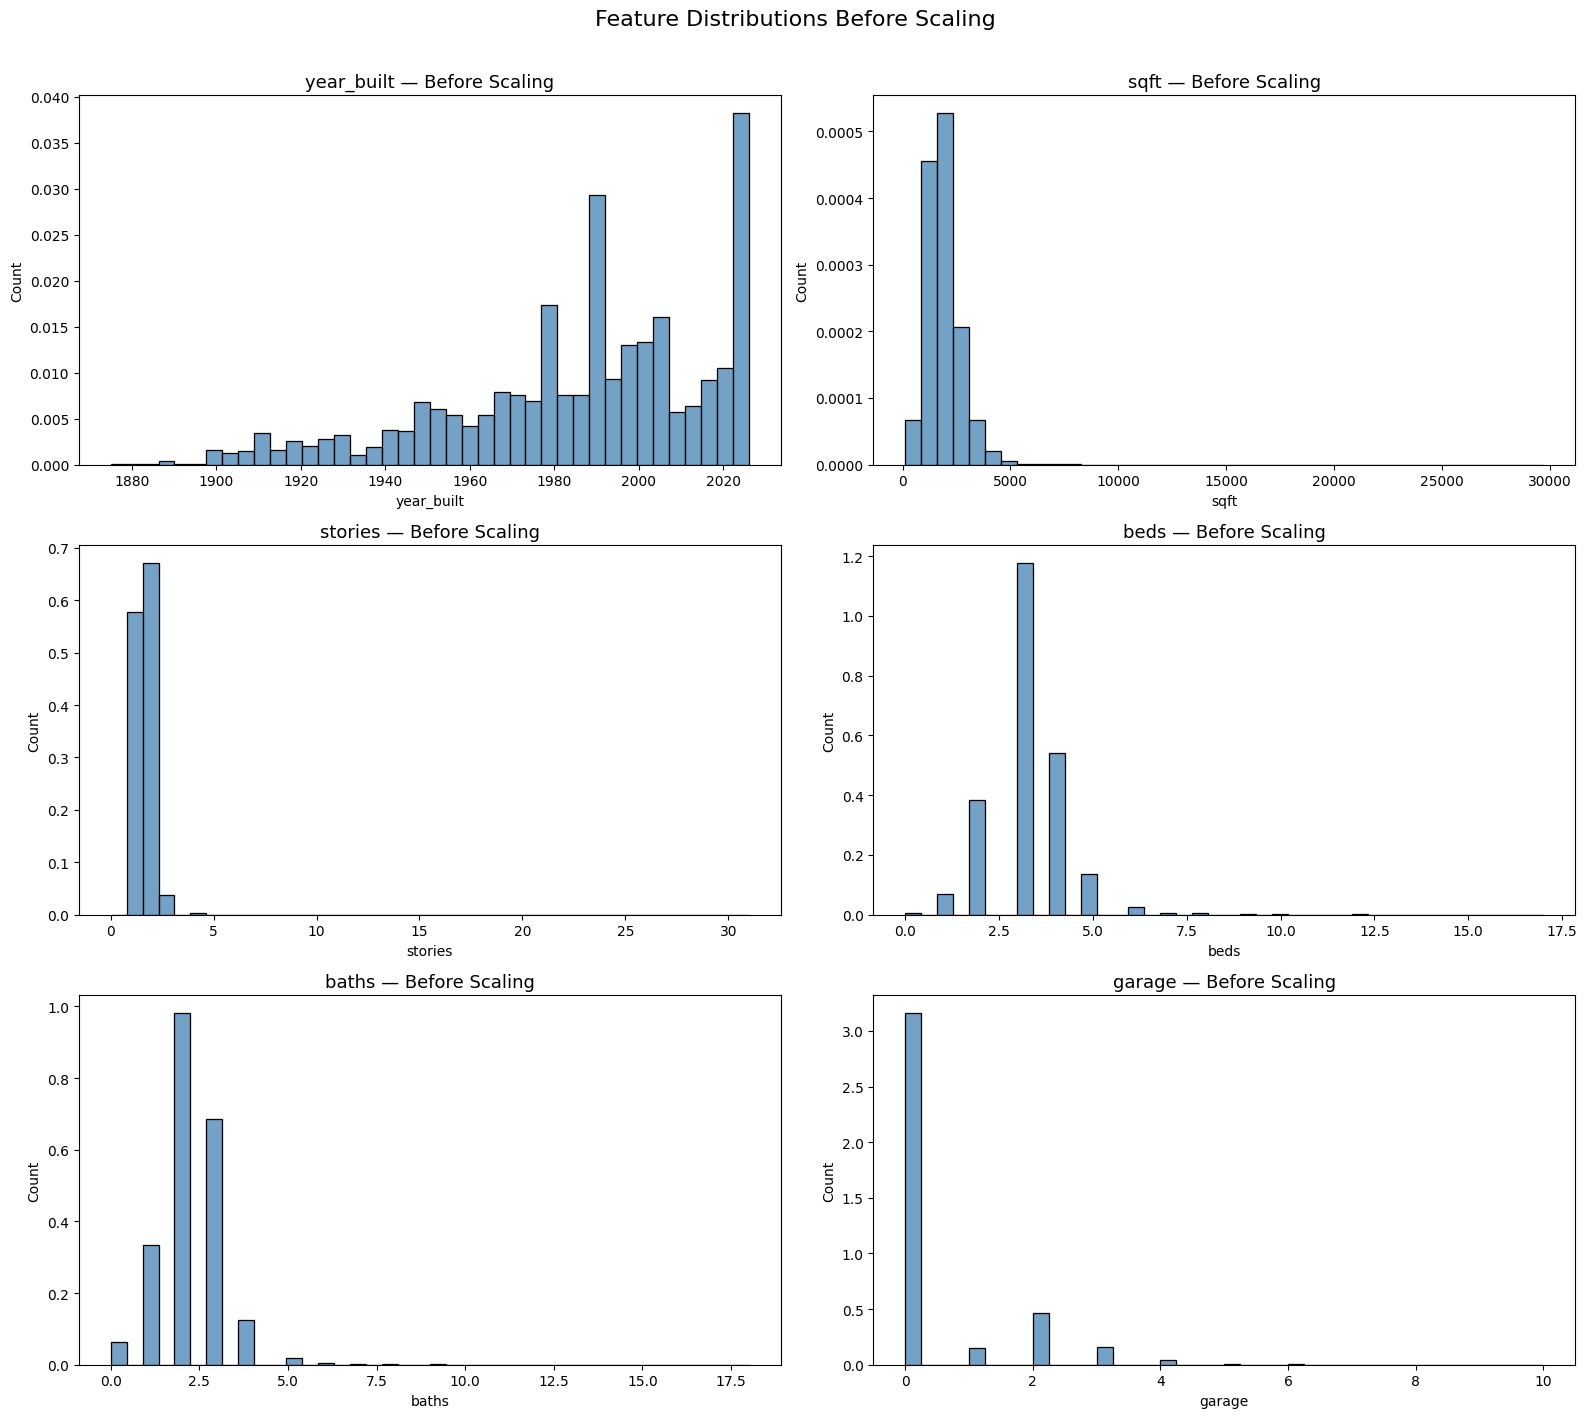

In [10]:
from sklearn.preprocessing import StandardScaler

# Features to scale — only numerical, not the one-hot encoded columns
numerical_cols = ['year_built', 'sqft', 'stories', 'beds', 'baths', 'garage']

#  BEFORE SCALING PLOT 
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, feature in enumerate(numerical_cols):
    sns.histplot(data=df_final, x=feature, ax=axes[i], bins=40, color='steelblue',stat = 'density')
    axes[i].set_title(f'{feature} — Before Scaling', fontsize=13)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')

plt.suptitle('Feature Distributions Before Scaling', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

In [11]:
#  APPLY STANDARD SCALING 
scaler = StandardScaler()

df_scaled_viz = df_final.copy()
df_scaled_viz[numerical_cols] = scaler.fit_transform(df_final[numerical_cols])

print("Before scaling — sqft mean/std:")
print(f"  mean: {df_final['sqft'].mean():.2f}, std: {df_final['sqft'].std():.2f}")
print("\nAfter scaling — sqft mean/std:")
print(f"  mean: {df_scaled_viz['sqft'].mean():.4f}, std: {df_scaled_viz['sqft'].std():.4f}")

Before scaling — sqft mean/std:
  mean: 1875.64, std: 828.29

After scaling — sqft mean/std:
  mean: -0.0000, std: 1.0000


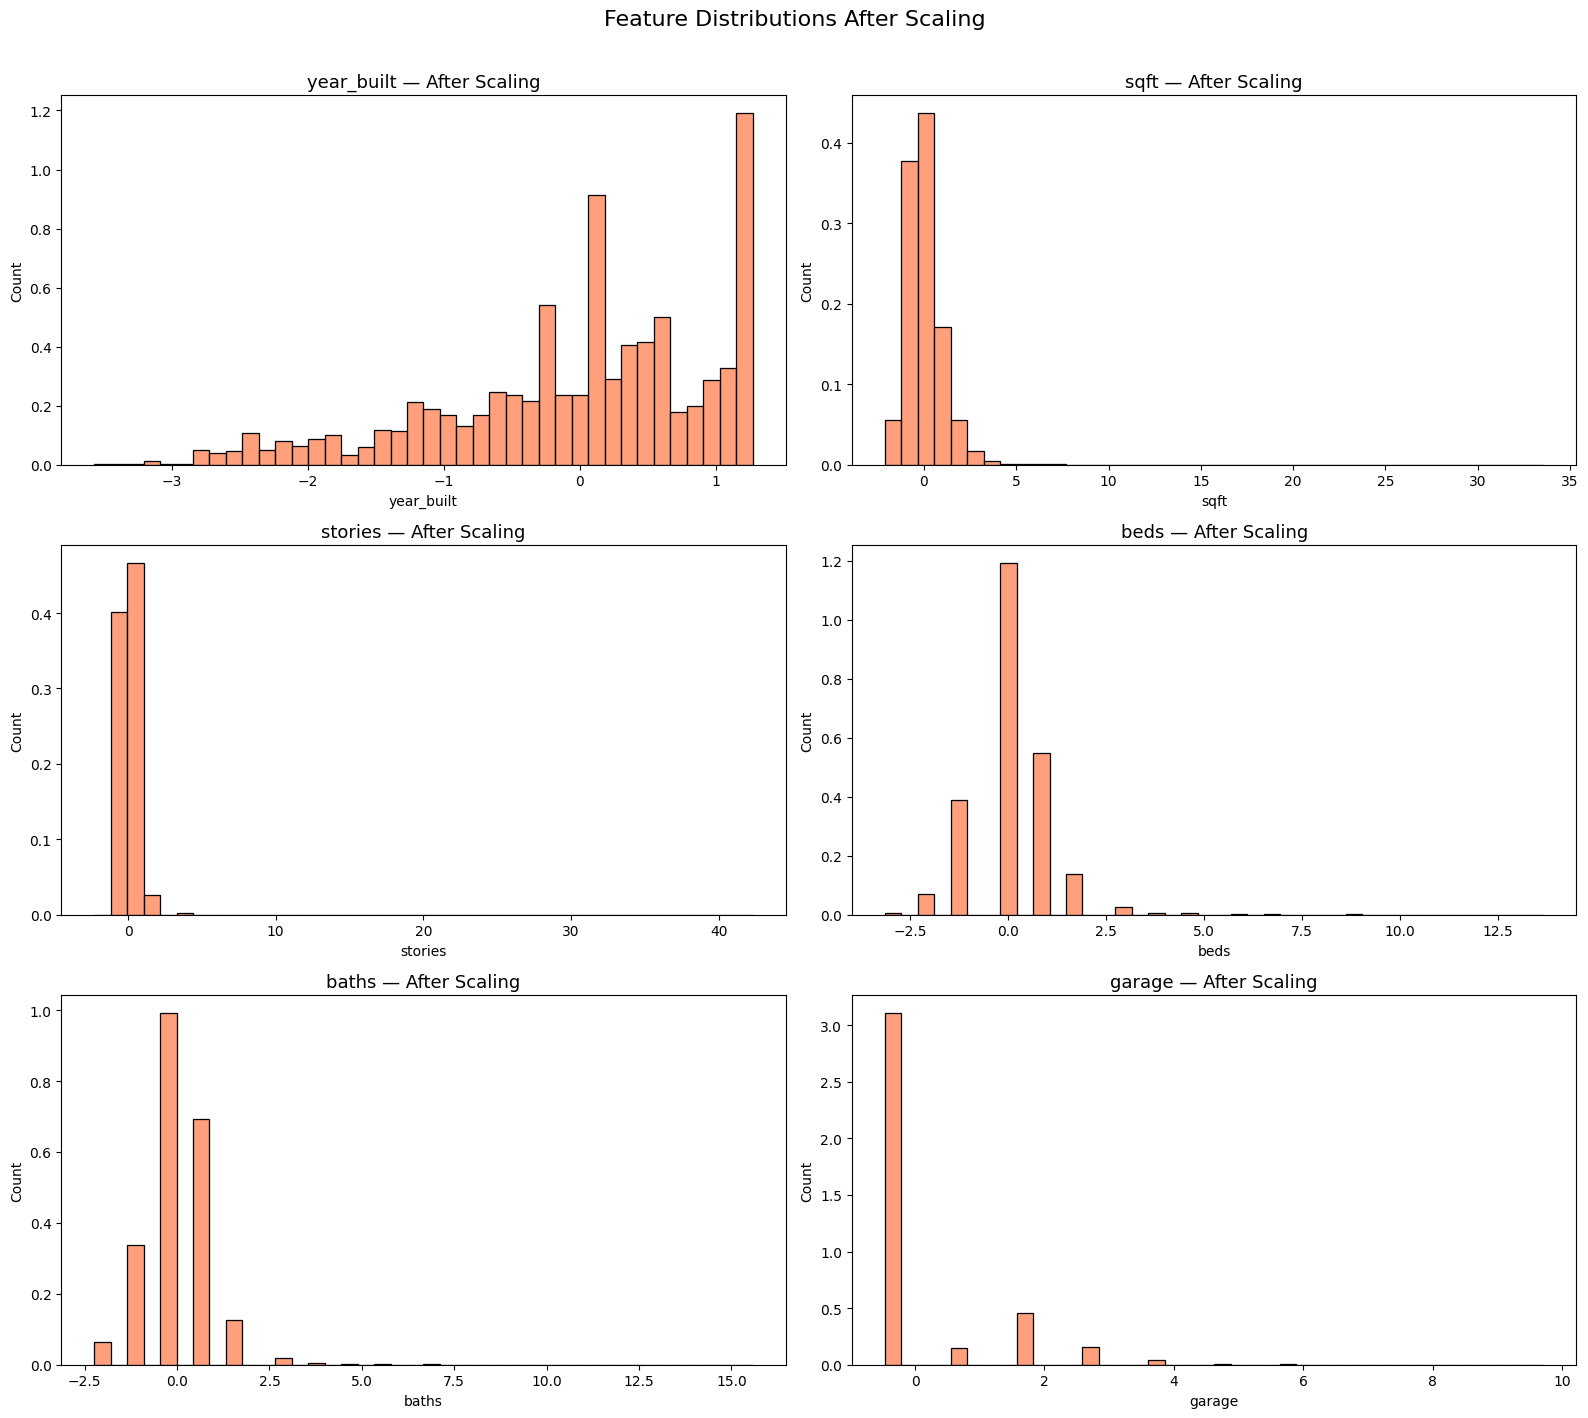

In [12]:
#  AFTER SCALING PLOT 
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, feature in enumerate(numerical_cols):
    sns.histplot(data=df_scaled_viz, x=feature, ax=axes[i], bins=40, color='coral',stat = 'density')
    axes[i].set_title(f'{feature} — After Scaling', fontsize=13)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')

plt.suptitle('Feature Distributions After Scaling', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

In [13]:
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

numerical_cols = ['year_built', 'sqft', 'stories', 'beds', 'baths', 'garage']

# 1. Define X and y BEFORE scaling
X = df_final.drop(columns=['lastSoldPrice'])
y = np.log1p(df_final['lastSoldPrice'])

# 2. Split FIRST
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)

# 3. Fit scaler on train only, apply to val and test
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_val[numerical_cols] = scaler.transform(X_val[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print(f"Train size:      {X_train.shape[0]} rows")
print(f"Validation size: {X_val.shape[0]} rows")
print(f"Test size:       {X_test.shape[0]} rows")

Train size:      7075 rows
Validation size: 1769 rows
Test size:       2211 rows


In [14]:
# 3. Train XGBoost
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=20,
    eval_metric='mae'
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50  # prints progress every 50 trees
)

[0]	validation_0-mae:0.45771
[50]	validation_0-mae:0.25736
[100]	validation_0-mae:0.24256
[150]	validation_0-mae:0.23645
[200]	validation_0-mae:0.23167
[250]	validation_0-mae:0.22901
[300]	validation_0-mae:0.22661
[350]	validation_0-mae:0.22404
[400]	validation_0-mae:0.22229
[450]	validation_0-mae:0.22095
[499]	validation_0-mae:0.21993


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,20
,enable_categorical,False
,eval_metric,'mae'


stories       0.001527
year_built    0.002253
beds          0.002344
garage        0.002643
sqft          0.009597
baths         0.015024
region        0.166387
zip_code      0.704341
dtype: float32


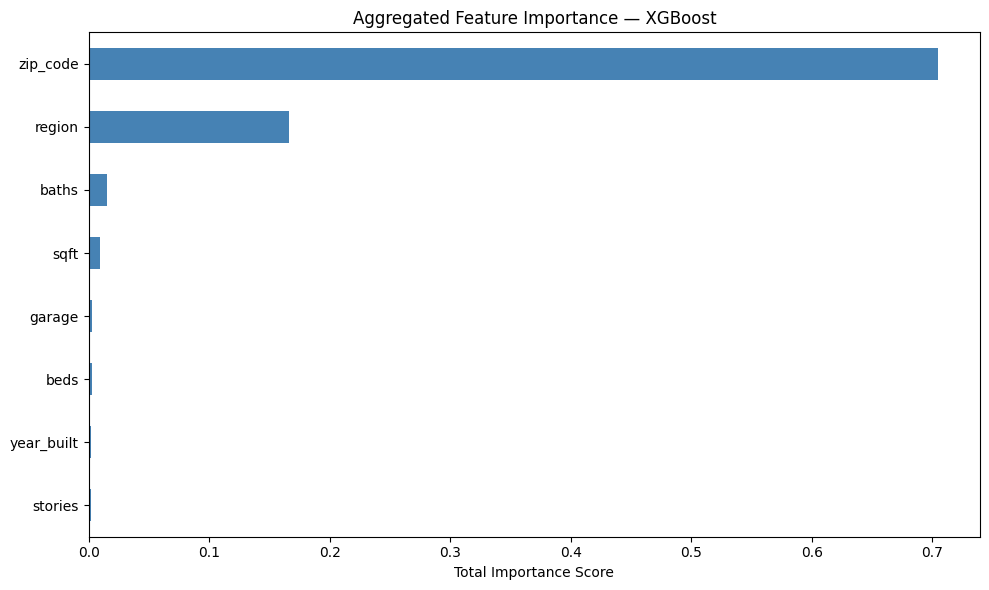

In [15]:
importance = pd.Series(model.feature_importances_, index=X_train.columns)

# Aggregate by feature group
zip_importance = importance[importance.index.str.startswith('zip_')].sum()
reg_importance = importance[importance.index.str.startswith('reg_')].sum()
sqft_importance = importance['sqft']
year_importance = importance['year_built']
baths_importance = importance['baths']
beds_importance = importance['beds']
stories_importance = importance['stories']
garage_importance = importance['garage']

summary = pd.Series({
    'zip_code': zip_importance,
    'region': reg_importance,
    'sqft': sqft_importance,
    'year_built': year_importance,
    'baths': baths_importance,
    'beds': beds_importance,
    'stories': stories_importance,
    'garage': garage_importance
}).sort_values(ascending=True)

print(summary)

summary.plot(kind='barh', figsize=(10, 6), color='steelblue')
plt.title('Aggregated Feature Importance — XGBoost')
plt.xlabel('Total Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

In [16]:
# 4. Validation performance
from sklearn.metrics import mean_absolute_error, r2_score

y_val_pred_log = model.predict(X_val)
y_val_actual = np.expm1(y_val)
y_val_pred_actual = np.expm1(y_val_pred_log)

mae_val = mean_absolute_error(y_val_actual, y_val_pred_actual)
r2_val = r2_score(y_val, y_val_pred_log)

print("── Validation Performance ──")
print(f"MAE: ${mae_val:,.2f}")
print(f"R²:  {r2_val:.4f}")

── Validation Performance ──
MAE: $105,701.88
R²:  0.7338


In [17]:
# 5. Test performance (final)
y_test_pred_log = model.predict(X_test)
y_test_actual = np.expm1(y_test)
y_test_pred_actual = np.expm1(y_test_pred_log)

mae_test = mean_absolute_error(y_test_actual, y_test_pred_actual)
r2_test = r2_score(y_test, y_test_pred_log)

print("── Test Performance (Final) ──")
print(f"MAE: ${mae_test:,.2f}")
print(f"R²:  {r2_test:.4f}")

── Test Performance (Final) ──
MAE: $105,205.66
R²:  0.6648


In [18]:
from sklearn.linear_model import Ridge

model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train, y_train)

y_val_pred_ridge = model_ridge.predict(X_val)
y_test_pred_ridge = model_ridge.predict(X_test)

mae_val_ridge = mean_absolute_error(np.expm1(y_val), np.expm1(y_val_pred_ridge))
r2_val_ridge = r2_score(y_val, y_val_pred_ridge)

mae_test_ridge = mean_absolute_error(np.expm1(y_test), np.expm1(y_test_pred_ridge))
r2_test_ridge = r2_score(y_test, y_test_pred_ridge)

print("── Ridge Validation ──")
print(f"MAE: ${mae_val_ridge:,.2f}")
print(f"R²:  {r2_val_ridge:.4f}")
print("\n── Ridge Test ──")
print(f"MAE: ${mae_test_ridge:,.2f}")
print(f"R²:  {r2_test_ridge:.4f}")

── Ridge Validation ──
MAE: $113,156.52
R²:  0.6820

── Ridge Test ──
MAE: $112,559.62
R²:  0.6287
